In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install librosa tensorflow scikit-learn seaborn

In [ ]:
import os

dataset_path = "/content/drive/MyDrive/multimodal_emotion_ Recognisation/TESS Toronto emotional speech set data"

print(os.listdir(dataset_path)[:5])

['OAF_angry', 'OAF_disgust', 'OAF_Fear', 'OAF_happy', 'OAF_neutral']


In [ ]:
import os
import librosa
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D
from tensorflow.keras.layers import MaxPooling1D
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.utils import to_categorical


# LOAD AUDIO FILES

audio_files = []
emotion_labels = []

print("Loading audio files...")

for root, dirs, files in os.walk(dataset_path):

    for file in files:

        if file.endswith(".wav"):

            file_path = os.path.join(root, file)

            emotion = file.split("_")[-1]
            emotion = emotion.replace(".wav", "")

            emotion = emotion.split(" ")[0]

            emotion = emotion.lower().strip()


            audio_files.append(file_path)
            emotion_labels.append(emotion)


print("Total Audio Files:", len(audio_files))

print("\nEmotion Classes:")
print(sorted(set(emotion_labels)))

Loading audio files...
Total Audio Files: 2802

Emotion Classes:
['angry', 'disgust', 'fear', 'happy', 'neutral', 'ps', 'sad']


In [6]:

# MFCC FEATURE EXTRACTION


X = []
y = []

print("Extracting MFCC features...")

for index, (file_path, emotion) in enumerate(zip(audio_files, emotion_labels)):

    try:

        audio, sr = librosa.load(
            file_path,
            sr=22050,
            mono=True
        )

        # EXTRACT MFCC FEATURES


        mfcc = librosa.feature.mfcc(
            y=audio,
            sr=sr,
            n_mfcc=40
        )


        mfcc = np.mean(mfcc.T, axis=0)


        X.append(mfcc)
        y.append(emotion)


        if (index + 1) % 200 == 0:

            print(f"Processed {index + 1}/{len(audio_files)} audio files")

    except Exception as e:

        print("\nError processing file:")
        print(file_path)
        print(e)

print("\nMFCC Feature Extraction Complete!")

Extracting MFCC features...
Processed 200/2802 audio files
Processed 400/2802 audio files
Processed 600/2802 audio files
Processed 800/2802 audio files
Processed 1000/2802 audio files
Processed 1200/2802 audio files
Processed 1400/2802 audio files
Processed 1600/2802 audio files
Processed 1800/2802 audio files
Processed 2000/2802 audio files
Processed 2200/2802 audio files
Processed 2400/2802 audio files
Processed 2600/2802 audio files
Processed 2800/2802 audio files

MFCC Feature Extraction Complete!


In [7]:
# DATA PREPARATION


X = np.array(X)
y = np.array(y)

print("Feature Shape:", X.shape)
print("Label Shape:", y.shape)


X = X.reshape(X.shape[0], X.shape[1], 1)


encoder = LabelEncoder()

y_encoded = encoder.fit_transform(y)


y_categorical = to_categorical(y_encoded)

print("\nEncoded Emotion Classes:")
print(encoder.classes_)

Feature Shape: (2802, 40)
Label Shape: (2802,)

Encoded Emotion Classes:
['angry' 'disgust' 'fear' 'happy' 'neutral' 'ps' 'sad']


In [8]:

# TRAIN TEST SPLIT


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_categorical,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("Training Samples:", X_train.shape[0])
print("Testing Samples:", X_test.shape[0])

Training Samples: 2241
Testing Samples: 561


In [9]:

# BUILD CNN + LSTM MODEL


model = Sequential()

# CNN Layer
model.add(
    Conv1D(
        filters=64,
        kernel_size=3,
        activation='relu',
        input_shape=(40,1)
    )
)

# Max Pooling
model.add(MaxPooling1D(pool_size=2))

# LSTM Layer
model.add(LSTM(64))

# Dropout
model.add(Dropout(0.3))

# Dense Layer
model.add(Dense(64, activation='relu'))

# Output Layer
model.add(Dense(y_categorical.shape[1], activation='softmax'))

# compile model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# summary
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 38, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 19, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 37,895 (148.03 KB)

 Trainable params: 37,895 (148.03 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:

# TRAIN MODEL


history = model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_data=(X_test, y_test)
)

# MODEL EVALUATION


loss, accuracy = model.evaluate(X_test, y_test)

print("\nFinal Accuracy:", accuracy)

Epoch 1/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step - accuracy: 0.5846 - loss: 1.1658 - val_accuracy: 0.7861 - val_loss: 0.6255
Epoch 2/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.8978 - loss: 0.3406 - val_accuracy: 0.8039 - val_loss: 0.4641
Epoch 3/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.9384 - loss: 0.1888 - val_accuracy: 0.9572 - val_loss: 0.1082
Epoch 4/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9585 - loss: 0.1222 - val_accuracy: 0.9127 - val_loss: 0.2498
Epoch 5/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9612 - loss: 0.1080 - val_accuracy: 0.9483 - val_loss: 0.1357
Epoch 6/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9750 - loss: 0.0810 - val_accuracy: 0.9768 - val_loss: 0.0668
Epoch 7/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9795 - loss: 0.0666 - val_accuracy: 0.9715 - val_loss: 0.0733
Epoch 8/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9795 - loss: 0.0609 - val_accuracy: 0.9501 - v

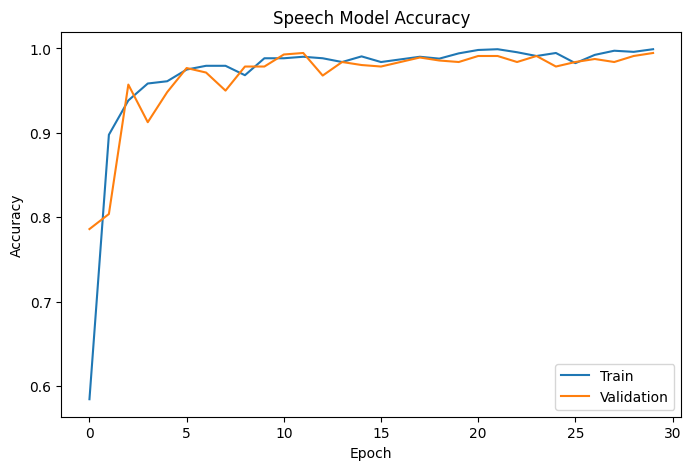

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


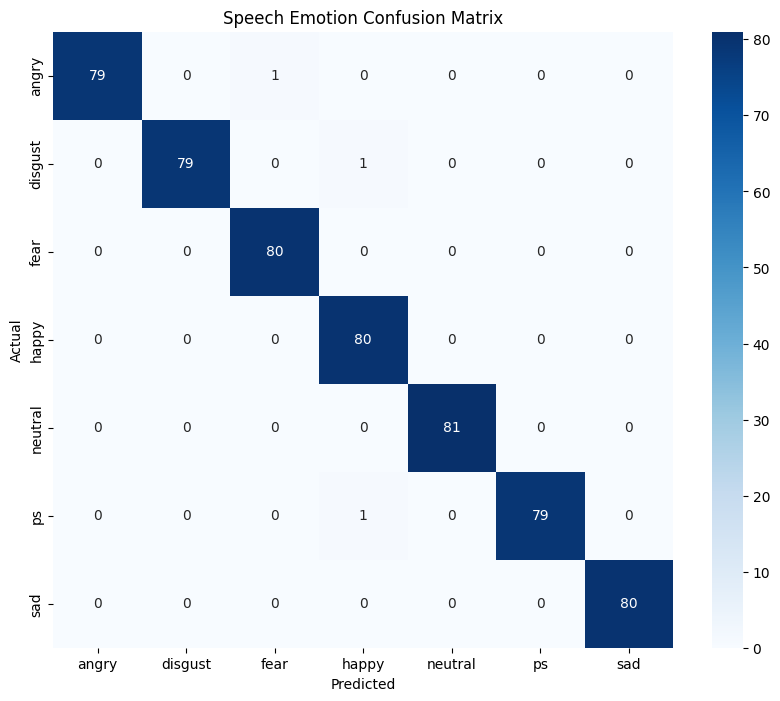



CLASSIFICATION REPORT
              precision    recall  f1-score   support

       angry       1.00      0.99      0.99        80
     disgust       1.00      0.99      0.99        80
        fear       0.99      1.00      0.99        80
       happy       0.98      1.00      0.99        80
     neutral       1.00      1.00      1.00        81
          ps       1.00      0.99      0.99        80
         sad       1.00      1.00      1.00        80

    accuracy                           0.99       561
   macro avg       0.99      0.99      0.99       561
weighted avg       0.99      0.99      0.99       561



In [11]:

# ACCURACY PLOT


plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Speech Model Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(['Train', 'Validation'])

plt.show()

# CONFUSION MATRIX


y_pred = model.predict(X_test)

y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Speech Emotion Confusion Matrix")

plt.show()

# CLASSIFICATION REPORT
print("\n")
print('CLASSIFICATION REPORT')

print(
    classification_report(
        y_true,
        y_pred_classes,
        target_names=encoder.classes_
    )
)

18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step


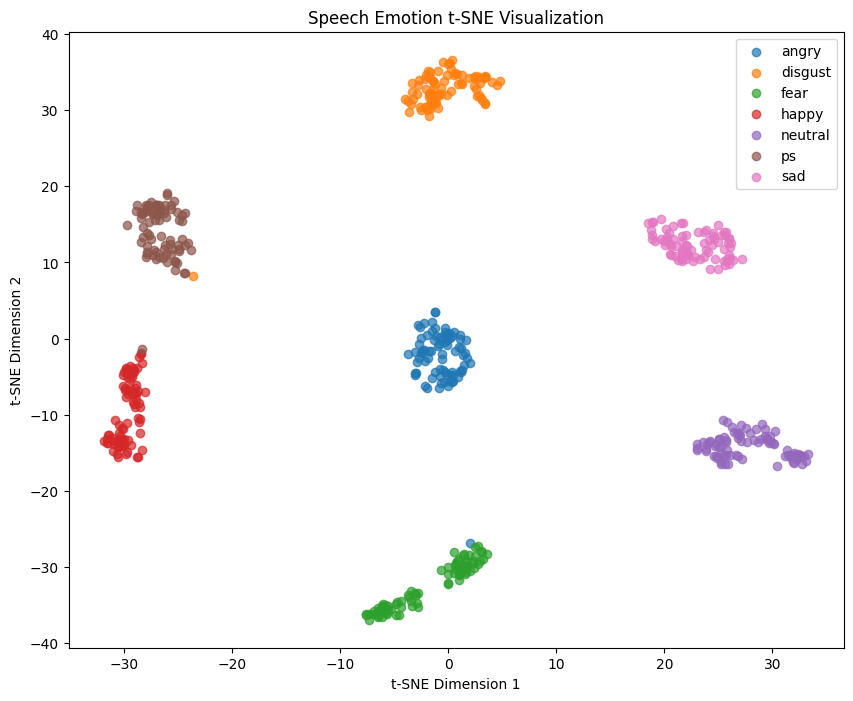

In [13]:

# t-SNE VISUALIZATION


from sklearn.manifold import TSNE
from tensorflow.keras.models import Model


feature_extractor = Model(
    inputs=model.inputs,
    outputs=model.layers[-2].output
)

speech_embeddings = feature_extractor.predict(X_test)


# APPLY t-SNE

tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=30
)

speech_tsne = tsne.fit_transform(speech_embeddings)

# VISUALIZATION


plt.figure(figsize=(10,8))

for emotion_index, emotion_name in enumerate(encoder.classes_):

    indices = np.where(y_true == emotion_index)

    plt.scatter(
        speech_tsne[indices, 0],
        speech_tsne[indices, 1],
        label=emotion_name,
        alpha=0.7
    )

plt.title("Speech Emotion t-SNE Visualization")

plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")

plt.legend()

plt.show()

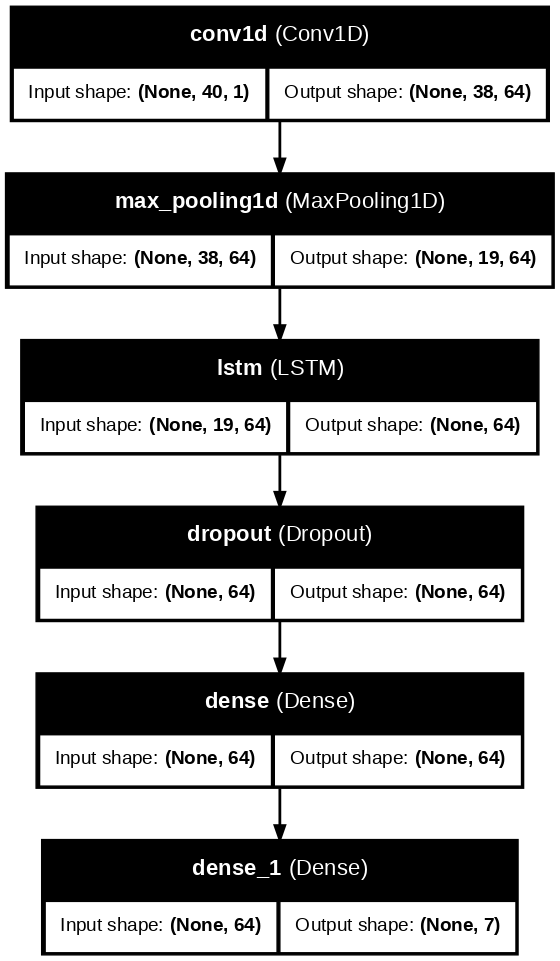

In [15]:

# ARCHITECTURE DIAGRAM

from tensorflow.keras.utils import plot_model

plot_model(
    model,
    show_shapes=True,
    show_layer_names=True,
    dpi=100
)

In [14]:

# SAVE MODEL


model.save("/content/drive/MyDrive/multimodal_emotion_ Recognisation/speech_emotion_model.keras")

print("Model Saved Successfully!")

Model Saved Successfully!
